# Applications of the lower bound of movement for Chagas detection (v1)

These notebook explains how the lower bounds of movement determinated in [Final Stats](EstadísticasFinales.ipynb) can be used for a detection algorithm.

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

Parameters for Färneback algorithm of the experiment

In [4]:
# Parameters of Färneback algoritm of the experiment
farneback_params = dict(
    pyr_scale=0.5,  # Image scale (<1) to build pyramids for each image
    levels=3,       # Number of pyramid layers
    winsize=15,     # Averaging window size
    iterations=3,   # Number of iterations at each pyramid level
    poly_n=5,       # Size of the pixel neighborhood for polynomial expansion
    poly_sigma=1.2, # Standard deviation for polynomial expansion
    flags=0         # Additional flags (optional)
    )

In [5]:
def MagnitudeTest(video, cota, n = 20, x0=0, x1 = 1920):
    # Storage
    storage = np.empty((0,2))
    
    ret, old_frame = video.read()
    if not ret:
        print('No hay video')

    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
    old_gray = old_gray[0:1080, x0:x1]

    for i in range(n):
        ret, frame = video.read()
        if not ret:
            break

        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame_gray = frame_gray[0:1080, x0:x1]

        #Calculate dense optical flow using Farneback method
        flow = cv2.calcOpticalFlowFarneback(old_gray, frame_gray, None, **farneback_params)
        old_gray = frame_gray

        # Compute magnitude and angle of the flow vectors
        magnitude, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])

        # Coordenates of selected values
        new_pts = np.column_stack(np.where(magnitude > cota))

        # Clustering sobre el primer frame
        new_detect = clustering(new_pts, min_pts = 25)

        # Remove duplications of coordenates
        storage = np.unique(np.vstack((storage, new_detect)), axis = 0)

    return storage

In [6]:
def clustering(pts, min_pts = 25, radius = 25):
    dbscan = DBSCAN(eps = radius, min_samples = min_pts) 
    labels = dbscan.fit_predict(pts)

    # Lista de clusters
    clusters = [k for k in set(labels) if k != -1]

    # Separación de puntos en su respectivo cluster
    ref_cluster = []
    for k in clusters:  # Dividir los puntos iniciales en los clusters
        puntos_en_cluster = [pts[i] for i in range(len(labels)) if labels[i] == k]
        pts_cluster = np.array(puntos_en_cluster)
        mean = int(len(pts_cluster)/2)
        ref_cluster.append(pts_cluster[mean]) # The representative is the half point of the cluster

    return(np.array(ref_cluster))

# Video without interface

In [8]:
Pos99, Pos95 = 2.4856, 1.8334 # Cotas de movimiento

In [9]:
video = cv2.VideoCapture('Videos/chagas42.MOV')
_, frame0 = video.read()

## Case for Pos99

In [11]:
pts = MagnitudeTest(video, Pos99, n = 100)

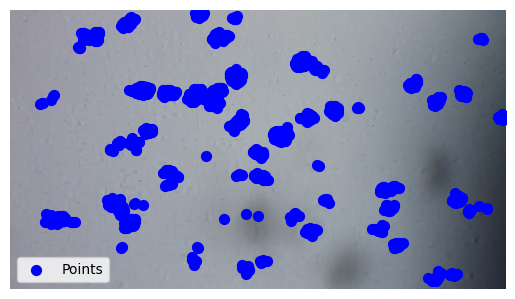

In [12]:
plt.imshow(frame0)
plt.scatter(pts[:,1], pts[:,0], color= "blue", s=50, label="Points")
# plt.title('Example video')
plt.legend()
plt.axis('off')
#plt.savefig('goodpts.png', bbox_inches='tight', pad_inches=0)
plt.show()

In [13]:
cluster = clustering(pts, min_pts = 10)

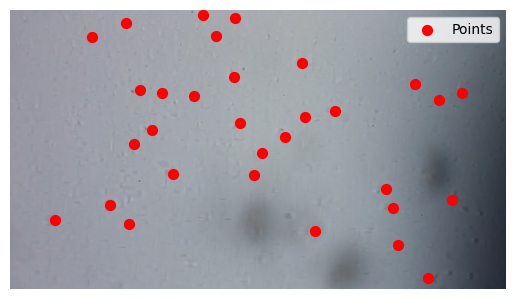

In [14]:
# Show image with the clusters representatives.
plt.imshow(frame0)
plt.scatter(cluster[:,1], cluster[:,0], color= "red", s=50, label="Points")  # Se usa como marcador el punto del intermedio
#plt.title('Example video')
plt.legend()
plt.axis('off')
# plt.savefig('clusters.png', bbox_inches='tight', pad_inches=0)
plt.show()

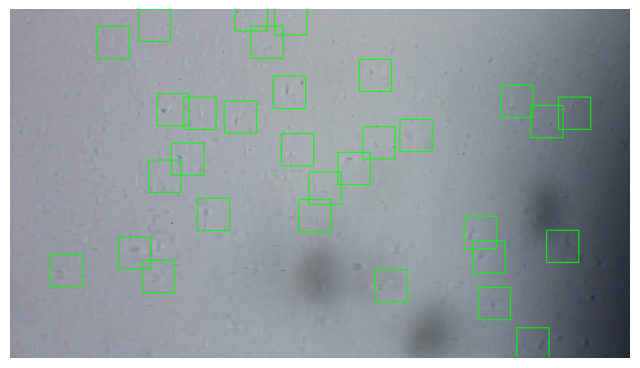

In [15]:
# Longitud del lado del cuadrado
radio = 50 

# Draw the rectangles over the image.
for (y, x) in cluster:
    top_left = (int(x) - radio, int(y) - radio)
    bottom_right = (int(x) + radio, int(y) + radio)
    cv2.rectangle(frame0, top_left, bottom_right, (0, 255, 0), 2)  # Color verde, grosor 2px

plt.figure(figsize=(8, 6))
plt.imshow(frame0)
#plt.title("Imagen con puntos y cuadrados")
plt.axis("off")
# plt.savefig('section.png', bbox_inches='tight', pad_inches=0)
plt.show()